In [39]:
%reload_ext autoreload
%autoreload 2

In [40]:
import jax 
import jax.numpy as jnp

from jax.typing import ArrayLike
from typing import NamedTuple

import matplotlib.pyplot as plt

import flax.nnx as nnx

from probjax.nn.nets.transformer import  Transformer, MLP

In [41]:
def random_split_like_tree(rng_key, target=None, treedef=None):
    if treedef is None:
        treedef = jax.tree_structure(target)
    keys = jax.random.split(rng_key, treedef.num_leaves)
    return jax.tree_unflatten(treedef, keys)


def tree_random_normal_like(rng_key, target):
    keys_tree = random_split_like_tree(rng_key, target)
    return jax.tree_map(
        lambda l, k: jax.random.normal(k, l.shape, l.dtype),
        target,
        keys_tree,
    )

In [42]:
from typing import Callable


class FunctionalComponent:
    def __init__(self, id: int, function: Callable):
        self.id = id
        self.function = function

    def __call__(self, mask: ArrayLike,x: ArrayLike):
        def true_fn():
            return self.function(x)
        def false_fn():
            return x
        
        return jax.lax.cond(mask[self.id], true_fn, false_fn)
    
class NormalComponent:
    def __init__(self, id: int, shape: tuple):
        self.id = id
        self.shape = shape

    def __call__(self, mask: ArrayLike, rng, params):
        std = params[self.id]
        std = std.reshape(self.shape)
        def true_fn():
            return jax.random.normal(rng, self.shape) * jax.nn.softplus(std) 
        def false_fn():
            return jnp.zeros(self.shape)
        
        return jax.lax.cond(mask[self.id], true_fn, false_fn)
    

        

In [126]:
NUM_COMPONENTS = 4

random_source = NormalComponent(0, ())
sin_component = FunctionalComponent(1, jnp.sin)
cos_component = FunctionalComponent(2, jnp.cos)
random_noise = NormalComponent(3, ())

NUM_SAMPLES = 100


PARAMS_STRUC = {0: jnp.array([1.]), 3: jnp.array([1.])}

COMPONENT_PARAMETERIZES = [i in PARAMS_STRUC for i in range(NUM_COMPONENTS)]

def prior_params(rng):
    # For now we will keep params fixed
    return tree_random_normal_like(rng, PARAMS_STRUC)



def f(component_mask, rng, params_model):
    rng1, rng2 = jax.random.split(rng)
    x = random_source(component_mask, rng1, params_model)
    y = sin_component(component_mask, x)
    z = cos_component(component_mask, y)
    eps = random_noise(component_mask, rng2, params_model)
    return z + eps


/tmp/ipykernel_596/3281511299.py:3: DeprecationWarning: jax.tree_structure is deprecated: use jax.tree.structure (jax v0.4.25 or newer) or jax.tree_util.tree_structure (any JAX version).
  treedef = jax.tree_structure(target)
/tmp/ipykernel_596/3281511299.py:5: DeprecationWarning: jax.tree_unflatten is deprecated: use jax.tree.unflatten (jax v0.4.25 or newer) or jax.tree_util.tree_unflatten (any JAX version).
  return jax.tree_unflatten(treedef, keys)
/tmp/ipykernel_596/3281511299.py:10: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  return jax.tree_map(


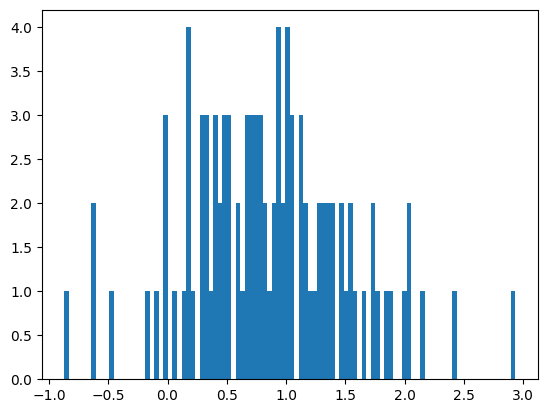

In [127]:
component_mask = jnp.array([True, True, True, True])  

model_params = prior_params(jax.random.PRNGKey(2))
rng = jax.random.PRNGKey(0)
keys = jax.random.split(rng, NUM_SAMPLES)
outputs = jax.vmap(f, in_axes=(0, 0, None))(jnp.stack([component_mask]*NUM_SAMPLES), keys, model_params)

_ = plt.hist(outputs.flatten(), bins=100)

In [128]:


def generate_data(rng_key, num_samples=NUM_SAMPLES):
    rng_key_model, rng_key_params, rng_data = jax.random.split(rng_key,3)
    #component_mask = jax.random.bernoulli(rng_key_model, p=0.7, shape=(NUM_COMPONENTS,))
    component_mask = jnp.array([True, True, True, True])
    keys = jax.random.split(rng_data, num_samples)
    params = prior_params(rng_key_params)
    outputs = jax.vmap(f, in_axes=[None,0,None])(component_mask, keys, params)


    return component_mask, outputs, params
    

In [129]:
_, xs, thetas = jax.vmap(generate_data)(jax.random.split(jax.random.key(0), 1000))

xs.shape, thetas[0].shape

/tmp/ipykernel_596/3281511299.py:3: DeprecationWarning: jax.tree_structure is deprecated: use jax.tree.structure (jax v0.4.25 or newer) or jax.tree_util.tree_structure (any JAX version).
  treedef = jax.tree_structure(target)
/tmp/ipykernel_596/3281511299.py:5: DeprecationWarning: jax.tree_unflatten is deprecated: use jax.tree.unflatten (jax v0.4.25 or newer) or jax.tree_util.tree_unflatten (any JAX version).
  return jax.tree_unflatten(treedef, keys)
/tmp/ipykernel_596/3281511299.py:10: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  return jax.tree_map(


((1000, 100), (1000, 1))

In [130]:
from models import ModelIdentificationDecoder, Simformer, EDM, ScalarTokenizer, VectorTokenizer, GaussianFourierEmbedding
import flax.nnx as nnx

tokenizer = ScalarTokenizer(2, value_dim=20, id_dim=30, cond_dim=0, context_dim=NUM_SAMPLES,rngs=nnx.Rngs(2))

model = EDM(Simformer(tokenizer, num_layers=4, rngs=nnx.Rngs(42)))


params = nnx.state(model, nnx.Param)

In [131]:
component_mask, data, params = generate_data(jax.random.PRNGKey(1))

/tmp/ipykernel_596/3281511299.py:3: DeprecationWarning: jax.tree_structure is deprecated: use jax.tree.structure (jax v0.4.25 or newer) or jax.tree_util.tree_structure (any JAX version).
  treedef = jax.tree_structure(target)
/tmp/ipykernel_596/3281511299.py:5: DeprecationWarning: jax.tree_unflatten is deprecated: use jax.tree.unflatten (jax v0.4.25 or newer) or jax.tree_util.tree_unflatten (any JAX version).
  return jax.tree_unflatten(treedef, keys)
/tmp/ipykernel_596/3281511299.py:10: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  return jax.tree_map(


In [132]:
from probjax.nn.loss_fn.denoising import build_time_dependent_denoising_loss

def mean_fn(t, x):
    return x

def std_fn(t, x):
    return model.std_fn(t) 

denoiser_loss_fn = build_time_dependent_denoising_loss(model, mean_fn=mean_fn, std_fn=std_fn, weight_fn=model.weight_fn, axis=-2)

In [133]:
import optax


optimizer = optax.adam(5e-4)




def loss_fn(params,key):
    key1, key2 = jax.random.split(key)
    keys = jax.random.split(key1, (1000,))
    _, data, theta_dict = jax.vmap(generate_data)(keys)

    theta_flat =  jnp.concatenate([theta_dict[i] for i in theta_dict], axis=-1).reshape(-1,2,1)
    key_time, key_loss = jax.random.split(key2)
    logt = jax.random.normal(key_time, shape=(1000, 1,1)) * 1.2 - 1.2
    node_id = jnp.arange(2).reshape(1,-1).repeat(1000, axis=0)
    t = jnp.exp(logt) + 0.0001

    loss = denoiser_loss_fn(params, t,theta_flat, node_ids=node_id, condition_mask=None,context=data.reshape(-1,1, NUM_SAMPLES), rng=key_loss)
    return loss


@jax.jit
def update(params, key, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, key)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [134]:
params = nnx.state(model, nnx.Param)
key = jax.random.PRNGKey(0)
opt_state = optimizer.init(params)    

In [135]:
loss_fn(params,key)

/tmp/ipykernel_596/3281511299.py:3: DeprecationWarning: jax.tree_structure is deprecated: use jax.tree.structure (jax v0.4.25 or newer) or jax.tree_util.tree_structure (any JAX version).
  treedef = jax.tree_structure(target)
/tmp/ipykernel_596/3281511299.py:5: DeprecationWarning: jax.tree_unflatten is deprecated: use jax.tree.unflatten (jax v0.4.25 or newer) or jax.tree_util.tree_unflatten (any JAX version).
  return jax.tree_unflatten(treedef, keys)
/tmp/ipykernel_596/3281511299.py:10: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  return jax.tree_map(


Array(9.559, dtype=float32)

In [136]:

for i in range(5_000):
    key, subkey, key2 = jax.random.split(key, 3)
    loss, params, opt_state = update(params,subkey, opt_state)
    if (i % 500) == 0:
        print(loss)

/tmp/ipykernel_596/3281511299.py:3: DeprecationWarning: jax.tree_structure is deprecated: use jax.tree.structure (jax v0.4.25 or newer) or jax.tree_util.tree_structure (any JAX version).
  treedef = jax.tree_structure(target)
/tmp/ipykernel_596/3281511299.py:5: DeprecationWarning: jax.tree_unflatten is deprecated: use jax.tree.unflatten (jax v0.4.25 or newer) or jax.tree_util.tree_unflatten (any JAX version).
  return jax.tree_unflatten(treedef, keys)
/tmp/ipykernel_596/3281511299.py:10: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  return jax.tree_map(


9.417672
1.4423182
1.3430636
1.3453337
1.2714576
1.2933512
1.2603234
1.2419088
1.1871367
1.1623335


In [137]:
nnx.update(model, params)

In [138]:
from probjax.utils.odeint import odeint

def naive_diffusion_sampling(key, x_o):
    T_end = 10.
    rng_init, _ = jax.random.split(key)
    eps = jax.random.normal(rng_init, (2,)) * model.marginal_std(T_end)
    ts = jnp.linspace(0.001, T_end, 100)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        x_ = x.reshape((1,2,1))
        f = model.drift(t,x_)
        g = model.diffusion(t, x_)
        score = model.score(t,x_, node_ids=jnp.arange(2)[None,], condition_mask=None, context=x_o)
        backward_f = (f -0.5*g**2*score).reshape(x.shape)
        return backward_f

    return odeint(drift, eps,ts[::-1], method="heun")[-1]

In [143]:
true_components, x_o, true_model_params = generate_data(jax.random.PRNGKey(0))

/tmp/ipykernel_596/3281511299.py:3: DeprecationWarning: jax.tree_structure is deprecated: use jax.tree.structure (jax v0.4.25 or newer) or jax.tree_util.tree_structure (any JAX version).
  treedef = jax.tree_structure(target)
/tmp/ipykernel_596/3281511299.py:5: DeprecationWarning: jax.tree_unflatten is deprecated: use jax.tree.unflatten (jax v0.4.25 or newer) or jax.tree_util.tree_unflatten (any JAX version).
  return jax.tree_unflatten(treedef, keys)
/tmp/ipykernel_596/3281511299.py:10: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  return jax.tree_map(


In [144]:
true_model_params

{0: Array([-0.279], dtype=float32), 3: Array([-0.752], dtype=float32)}

In [145]:
params_sampled = jax.vmap(lambda k: naive_diffusion_sampling(k, x_o[None,:]))(jax.random.split(jax.random.PRNGKey(1), 1000))

(-4.0, 4.0)

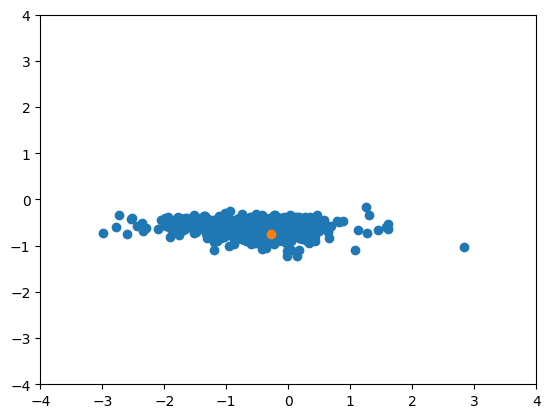

In [146]:
plt.scatter(params_sampled[:,0], params_sampled[:,1])
plt.scatter(true_model_params[0], true_model_params[3])
plt.ylim(-4,4)
plt.xlim(-4,4)

In [ ]:

x_pred = jax.vmap(lambda key : f(samples_mask[0], key, prior_params(key)))(jax.random.split(jax.random.PRNGKey(0), 500))

NameError: name 'samples_mask' is not defined

(array([ 1.,  0.,  0.,  0.,  1.,  1.,  1.,  0.,  1.,  0.,  2.,  0.,  2.,
         3.,  4.,  2.,  5.,  6.,  6.,  3.,  6.,  7.,  2.,  5., 11.,  2.,
         9.,  5.,  4.,  8., 14., 16., 10.,  9.,  9.,  6.,  9.,  8.,  9.,
        15., 11., 13., 11.,  9., 13., 12.,  9., 15., 12.,  6., 15., 10.,
         7.,  8., 10.,  8., 11.,  6.,  7.,  4.,  5.,  6.,  9.,  8.,  7.,
         5.,  2.,  5.,  6.,  3.,  8.,  3.,  6.,  5.,  2.,  6.,  3.,  1.,
         2.,  1.,  1.,  2.,  1.,  1.,  0.,  1.,  0.,  0.,  0.,  1.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([-2.047, -1.998, -1.949, -1.9  , -1.851, -1.803, -1.754, -1.705,
        -1.656, -1.607, -1.559, -1.51 , -1.461, -1.412, -1.364, -1.315,
        -1.266, -1.217, -1.168, -1.12 , -1.071, -1.022, -0.973, -0.924,
        -0.876, -0.827, -0.778, -0.729, -0.681, -0.632, -0.583, -0.534,
        -0.485, -0.437, -0.388, -0.339, -0.29 , -0.241, -0.193, -0.144,
        -0.095, -0.046,  0.003,  0.051,  0.1  ,  0.149,  0.198,  0.246,
  

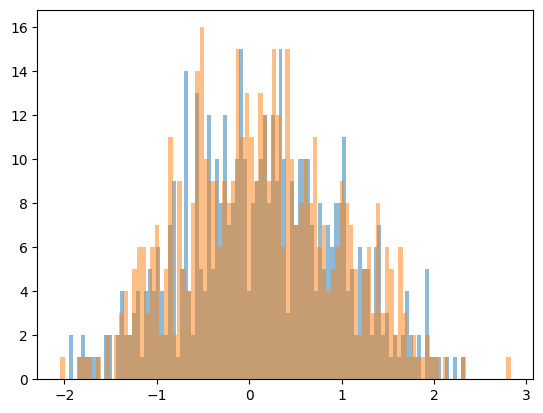

In [ ]:
plt.hist(x_pred.flatten(), bins=100, alpha=0.5)
plt.hist(data.flatten(), bins=100, alpha=0.5)

In [ ]:
input[0]

Array([ True, False,  True,  True], dtype=bool)

In [ ]:
params_model

[Array([[ 0.001, -0.034]], dtype=float32),
 Array([[ 0.339, -0.   ]], dtype=float32)]

In [ ]:
input[0]

Array([ True, False,  True,  True], dtype=bool)

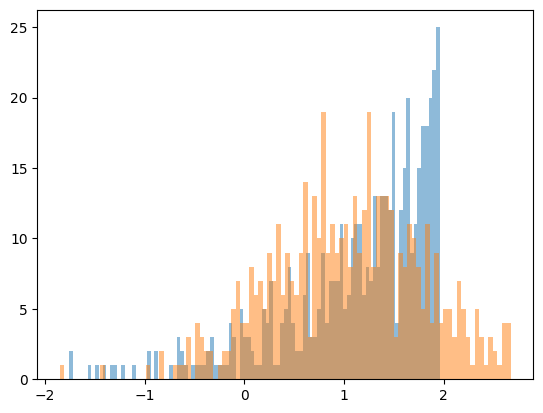

In [ ]:
_ = plt.hist(x_pred.flatten(), bins=100, alpha=0.5)
_ = plt.hist(input[1].flatten(), alpha=0.5, bins=100)

In [ ]:
input[2]

{0: Array([ 1.848, -0.301], dtype=float32),
 3: Array([-0.788, -1.355], dtype=float32)}